# 📐 Geometric Derivative — My Study Notes

These are my handwritten notes from a study session on **geometric intuition for derivatives**.

The big idea I was exploring: **what does $\frac{df}{dx}$ actually mean geometrically?**

The answer I landed on: it's the **rate at which the function changes per unit change in $x$** — or equivalently, the **slope of the tangent line** to the graph at a point.

I want to build this up from scratch using only geometry and algebra, no limit machinery yet.


In [7]:
from IPython.display import Image, display
import os

# The notebook lives in calculus/, so study_notes/ is right next to it
img_dir = os.path.join(os.getcwd(), "study_notes")
images = sorted([f for f in os.listdir(img_dir) if f.lower().endswith((".png", ".jpg", ".jpeg"))])
print(f"Found {len(images)} images:")
for f in images:
    print(" ", f)


Found 7 images:
  image-1773788407197.png
  image-1773788421237.png
  image-1773788452649.png
  image-1773788470518.png
  image-1773788489269.png
  image-1773788504572.png
  image-1773788519331.png


## 1️⃣ What does $\frac{df}{dx}$ mean?

Before anything else I asked myself: **what does this symbol actually mean?**

My answer: it means the **rate at which the function changes per unit change in $x$**.

For a monomial like $f(x) = x^2$, I want to find out **how much does $y$ change** when I nudge $x$ by a tiny amount $dx$.

The key move is:
$$y + dy = (x + dx)^2$$

I am looking for $dy$ — the **change in $y$** — given a change $dx$ in $x$.

Another way to say it: $\frac{df}{dx}$ is the **slope of the tangent line** to the graph of $f$ at the point $x$.


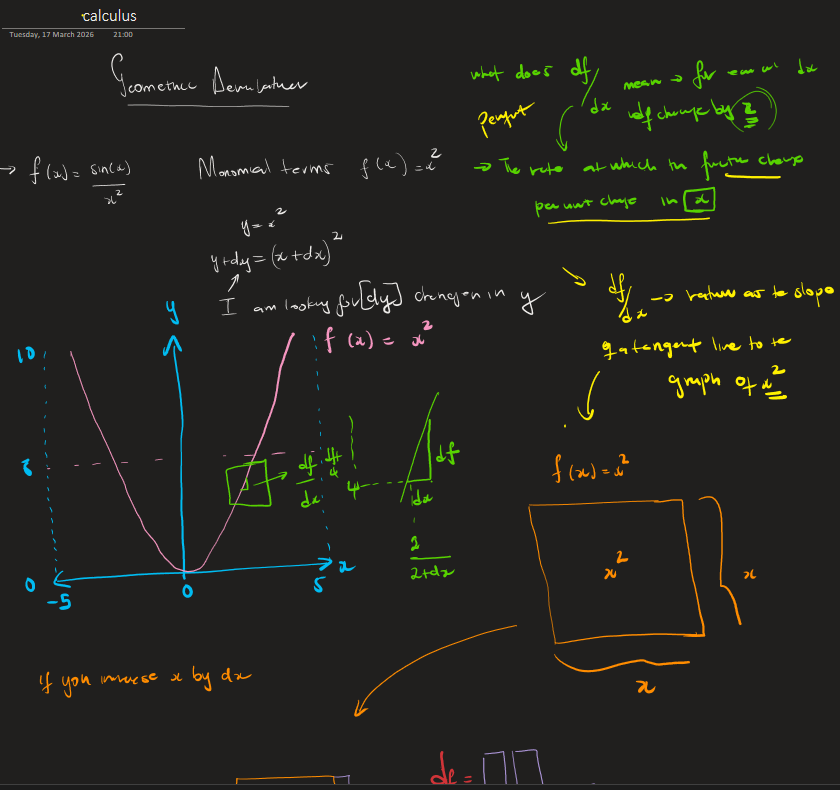

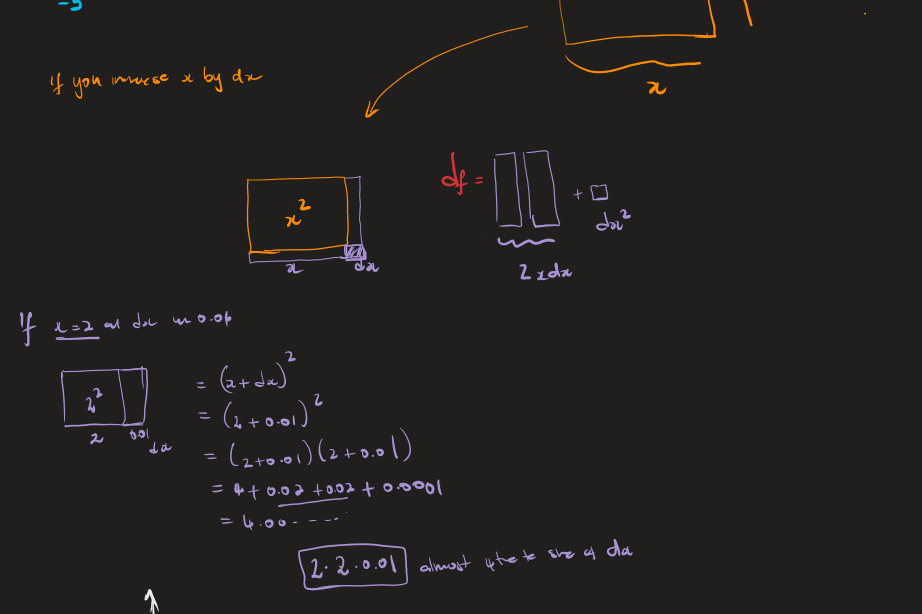

In [8]:
# My notes — pages 1 & 2: geometric setup and the question
display(Image(os.path.join(img_dir, images[0])))
display(Image(os.path.join(img_dir, images[1])))


## 2️⃣ The area view — $f(x) = x^2$

I thought about $y = x^2$ as the **area of a square** with side $x$.

If I increase the side by $dx$, I get a new bigger square of side $(x + dx)$. The new area is:

$$y + dy = (x + dx)^2 = x^2 + 2x \cdot dx + (dx)^2$$

The **change in area** is:

$$dy = 2x \cdot dx + (dx)^2$$

Geometrically this is:
- **Two slabs** of area $x \cdot dx$ (one on the right, one on the top of the original square)
- **One tiny corner square** of area $(dx)^2$

Now I ask: **if $dx$ is tiny, what is left?**

When $dx$ is very small, $(dx)^2$ becomes negligible — it disappears much faster than $dx$ itself. So the dominant change is just the two slabs:

$$dy \approx 2x \cdot dx$$

Dividing both sides by $dx$:

$$\frac{dy}{dx} = 2x + dx \xrightarrow{dx \to 0} \boxed{2x}$$

**Meaning:** for a unit increase in $x$, $y$ changes by $2x$. That's the derivative.


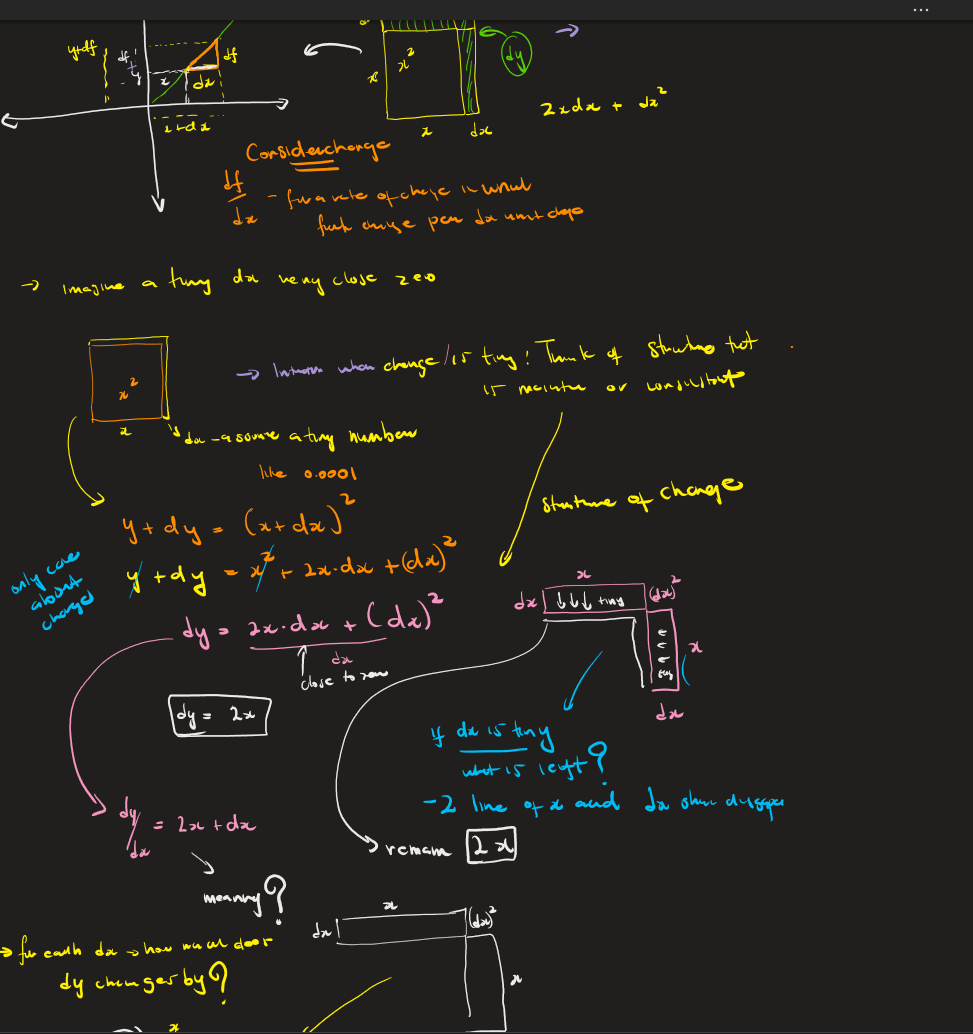

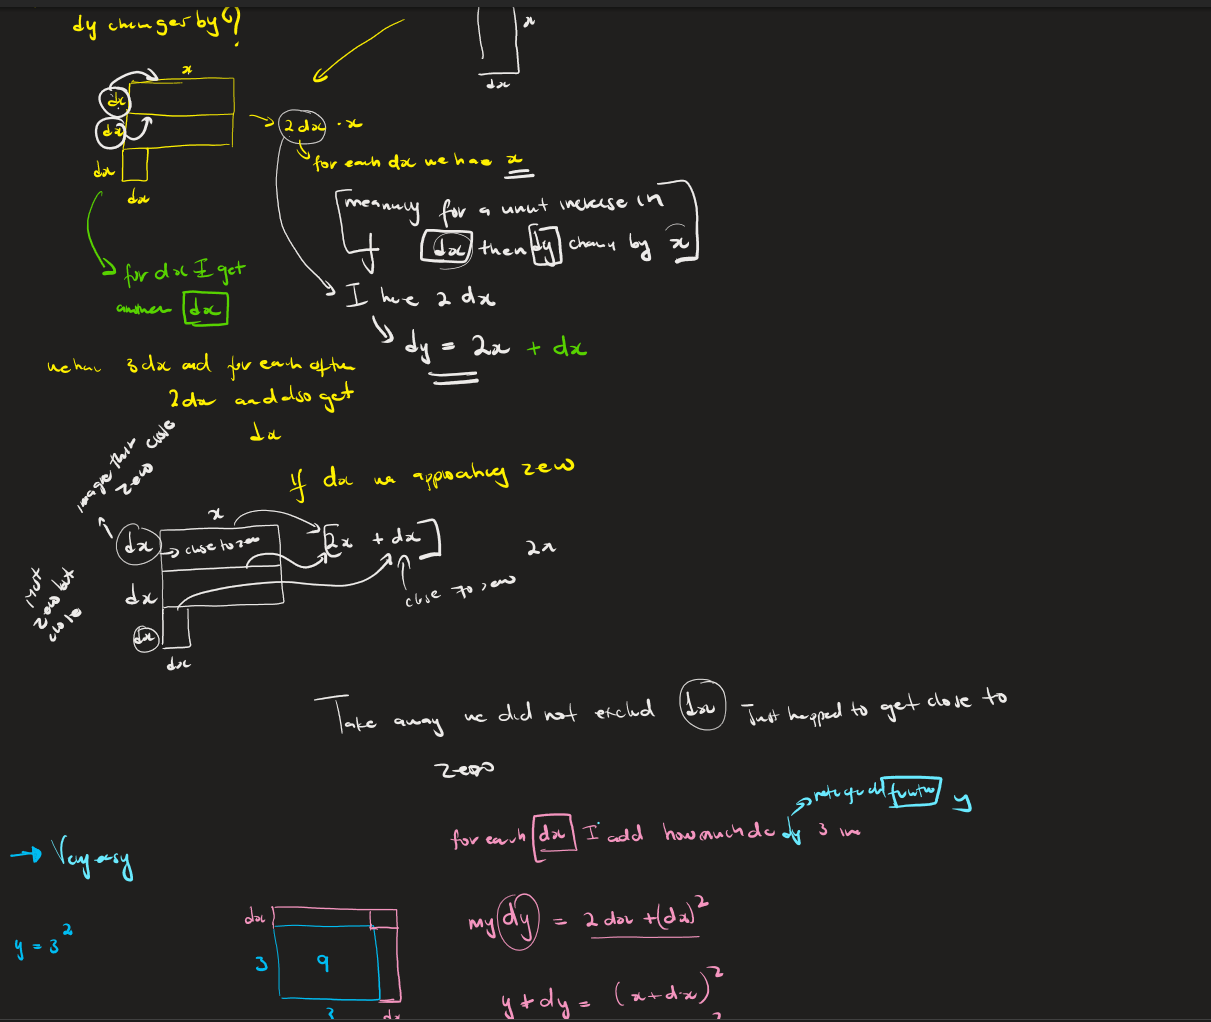

In [9]:
# My notes — pages 3 & 4: the area argument and consider change
display(Image(os.path.join(img_dir, images[2])))
display(Image(os.path.join(img_dir, images[3])))


## 3️⃣ Numerical check — $x = 2$, $dx = 0.01$

I did a concrete check in my notes. If $x = 2$ and $dx = 0.01$:

$$y + dy = (2 + 0.01)^2 = (2.01)^2 = 4 + 0.02 + 0.02 + 0.0001 = 4.0401$$

So $dy = 0.0401$.

The formula predicts $dy \approx 2 \cdot 2 \cdot 0.01 = 0.04$. The tiny leftover is $(0.01)^2 = 0.0001$ — almost nothing.

**This confirmed to me that $2x$ really is the right answer** — the $(dx)^2$ term is irrelevant for small $dx$.


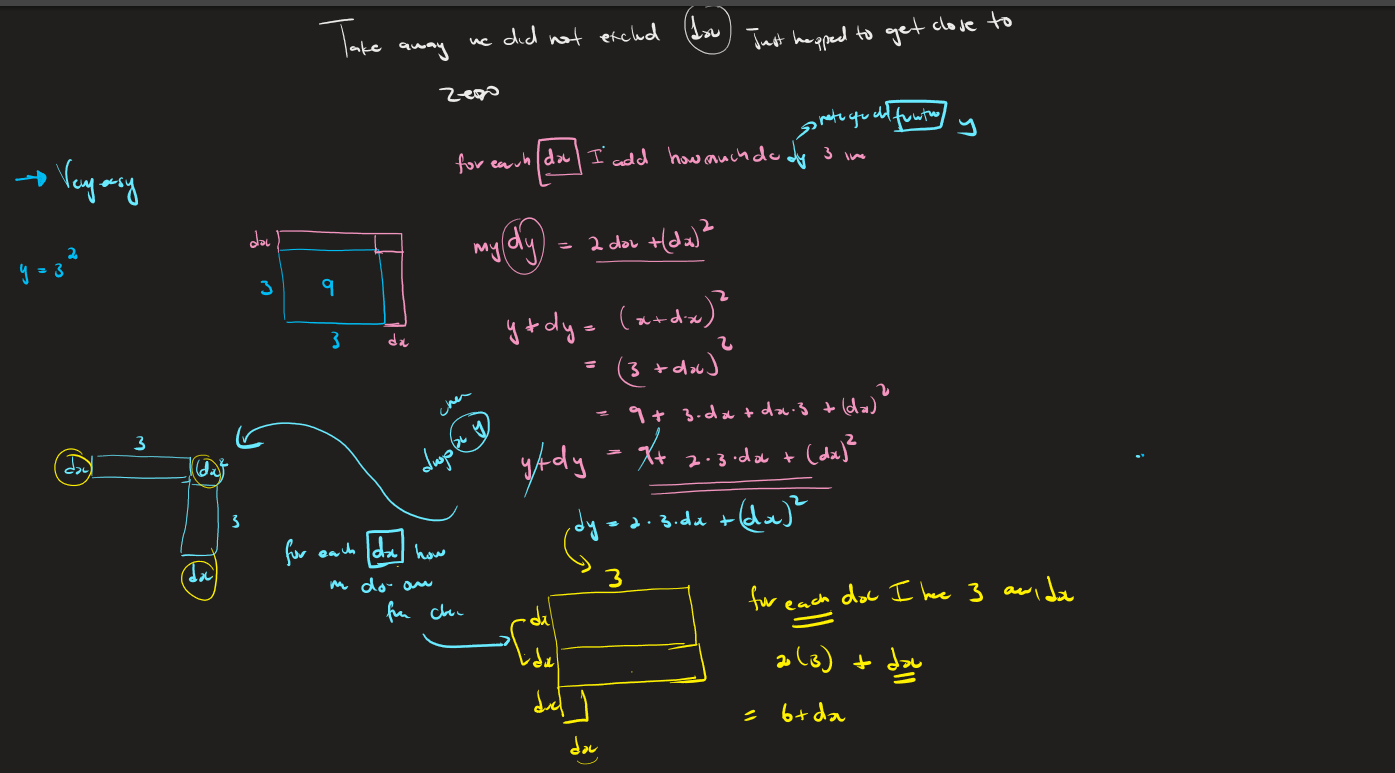

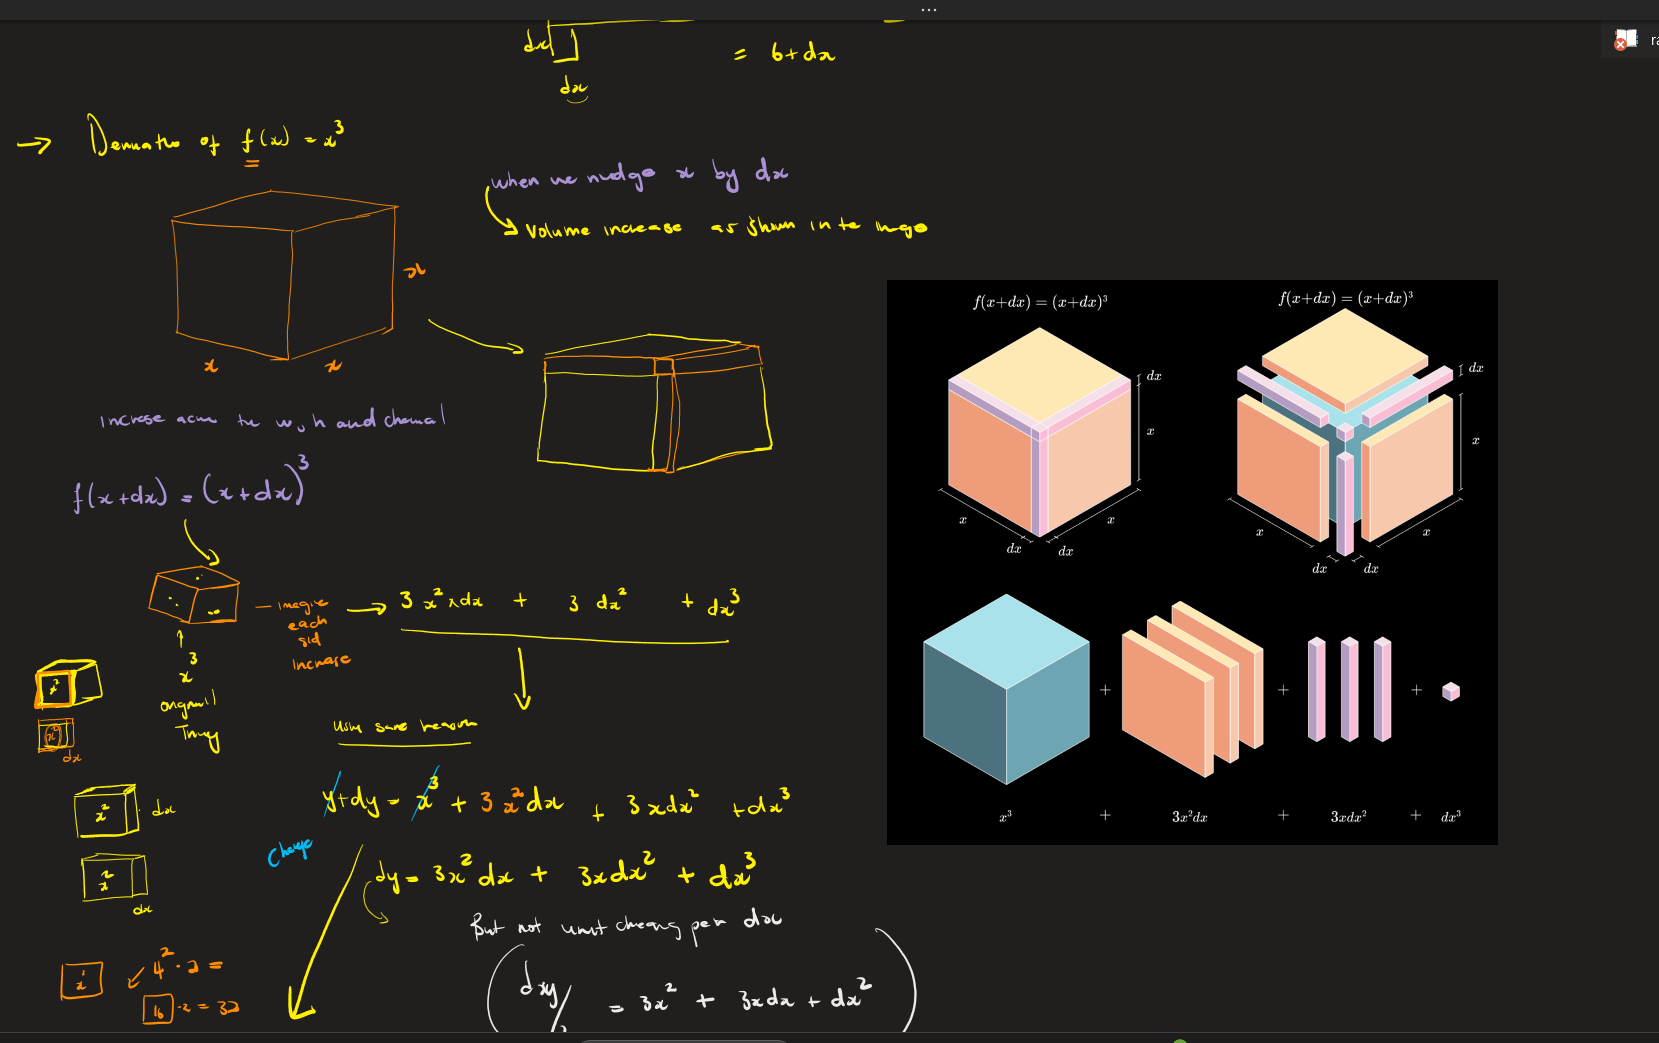

In [10]:
# My notes — pages 5 & 6: numerical check and dy = 2x + dx discussion
display(Image(os.path.join(img_dir, images[4])))
display(Image(os.path.join(img_dir, images[5])))


## 4️⃣ The volume view — $f(x) = x^3$

Now I did the same thing for $f(x) = x^3$, thinking about a **cube** with side $x$ and volume $x^3$.

When I increase the side by $dx$, the new volume is:

$$(x + dx)^3 = x^3 + 3x^2 \cdot dx + 3x \cdot (dx)^2 + (dx)^3$$

So the **change in volume** is:

$$dy = 3x^2 \cdot dx + 3x \cdot (dx)^2 + (dx)^3$$

And the **change per unit of $dx$** is:

$$\frac{dy}{dx} = 3x^2 + 3x \cdot dx + (dx)^2$$

When $dx \to 0$ the last two terms vanish:

$$\boxed{\frac{d}{dx} x^3 = 3x^2}$$

### What are the three pieces geometrically?

I found this really satisfying to visualise. When you nudge a cube of side $x$ by $dx$:

| Piece | Count | Volume | Dominant? |
|---|---|---|---|
| Flat slabs ($x \times x \times dx$) | 3 | $3x^2 \cdot dx$ | ✅ yes |
| Thin rods ($x \times dx \times dx$) | 3 | $3x \cdot (dx)^2$ | ❌ vanishes |
| Tiny cube corner ($dx \times dx \times dx$) | 1 | $(dx)^3$ | ❌ vanishes |

Only the **three flat slabs survive** as $dx \to 0$. That's where $3x^2$ comes from.


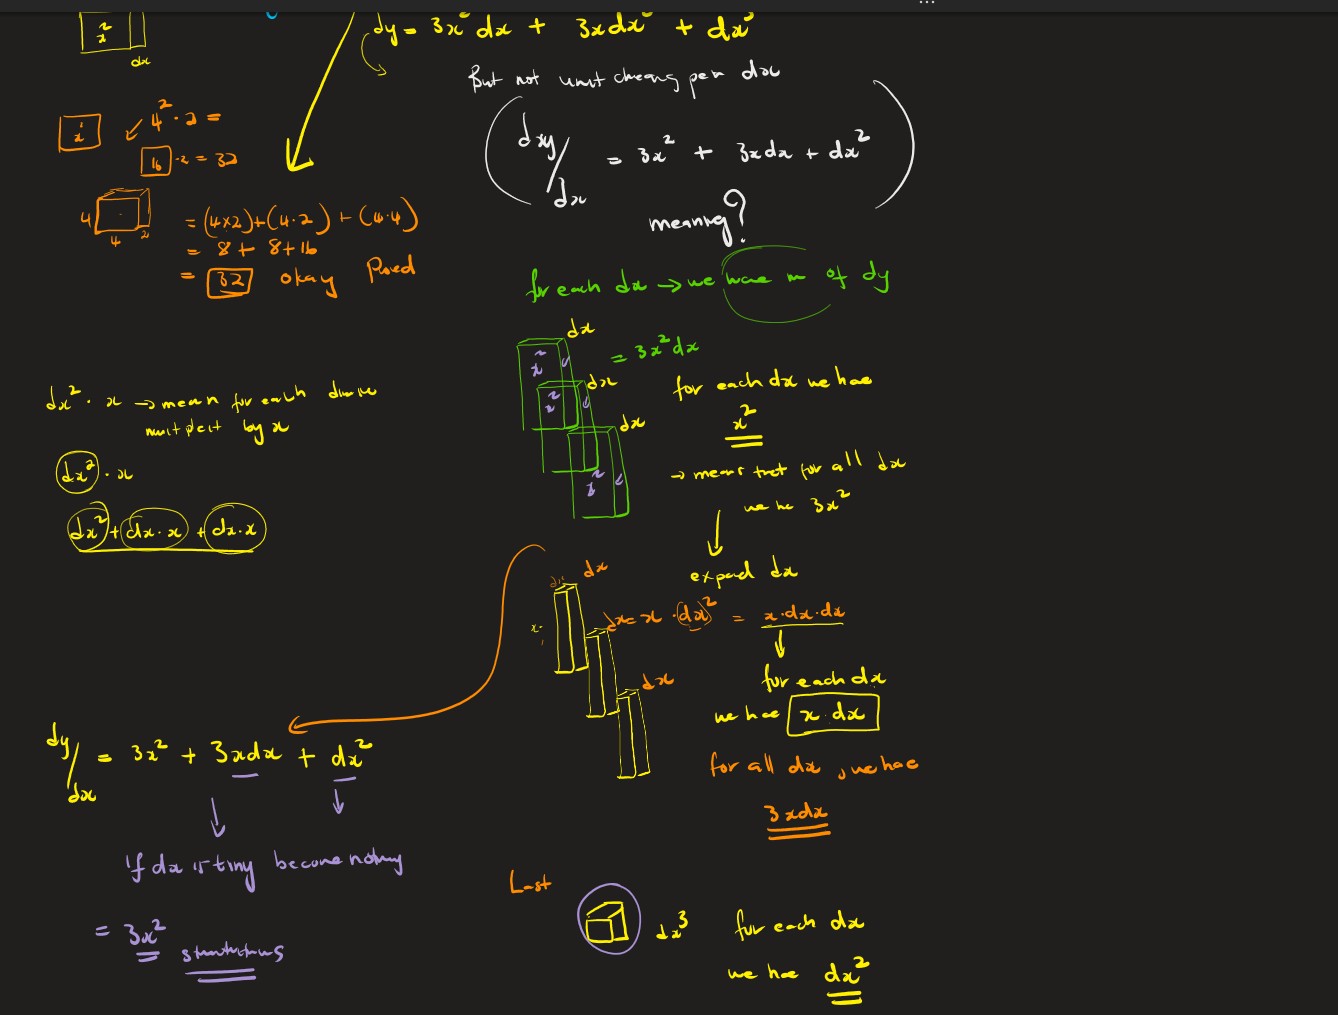

In [11]:
# My notes — page 7: the cube decomposition
display(Image(os.path.join(img_dir, images[6])))


## 5️⃣ The big takeaway — neglecting higher order terms

The pattern I see across both examples is the same:

1. **Expand** $f(x + dx)$ using algebra.
2. **Subtract** $f(x)$ to get $dy$.
3. **Divide** by $dx$.
4. **Let $dx \to 0$** — all terms with $dx$ still in them vanish.

Whatever survives step 4 is the derivative.

The geometric versions make this feel natural rather than mechanical:
- For $x^2$: only the **two slabs** survive the shrink → derivative $= 2x$
- For $x^3$: only the **three flat faces** survive the shrink → derivative $= 3x^2$

The **pattern is obvious**: for $x^n$, the derivative is $nx^{n-1}$.

I didn't "exclude" $dx$ — I just **let it approach zero** and it disappeared on its own. That's the whole trick.


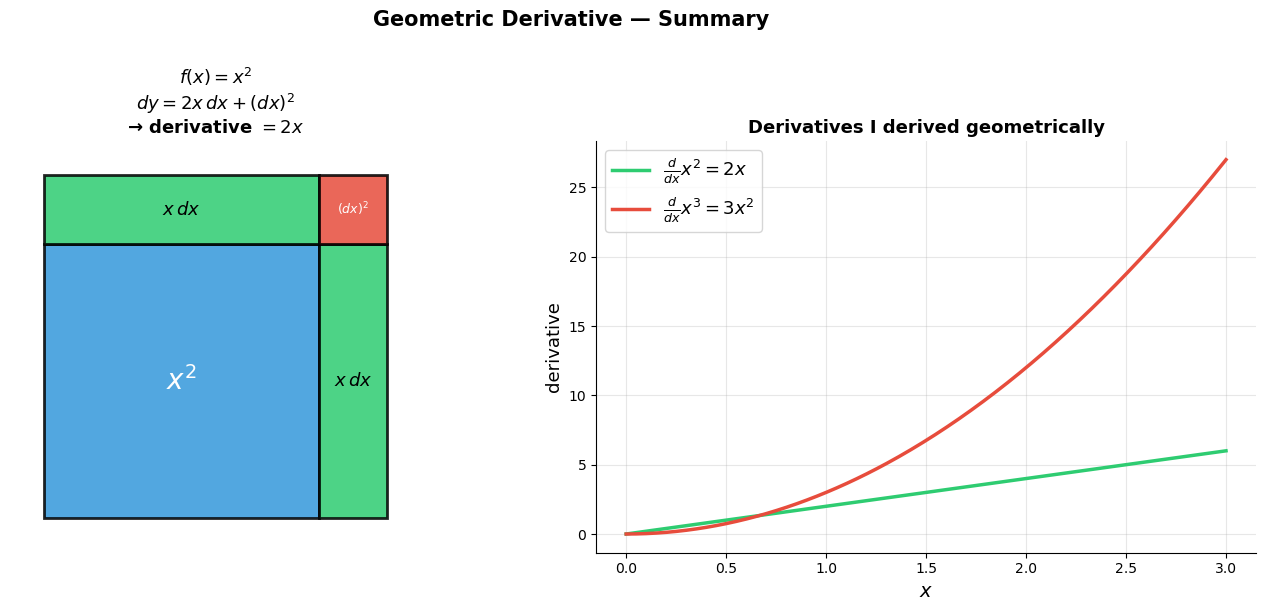

In [12]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ── Left: the growing square ──────────────────────────────────────────────────
ax = axes[0]
x, dx = 4, 1.0

ax.add_patch(patches.FancyBboxPatch((0, 0), x, x, boxstyle="square,pad=0",
    facecolor='#3498db', edgecolor='black', lw=2, alpha=0.85))
ax.text(x/2, x/2, '$x^2$', ha='center', va='center', fontsize=20, color='white', fontweight='bold')

ax.add_patch(patches.FancyBboxPatch((x, 0), dx, x, boxstyle="square,pad=0",
    facecolor='#2ecc71', edgecolor='black', lw=2, alpha=0.85))
ax.text(x + dx/2, x/2, '$x\\,dx$', ha='center', va='center', fontsize=13, fontweight='bold')

ax.add_patch(patches.FancyBboxPatch((0, x), x, dx, boxstyle="square,pad=0",
    facecolor='#2ecc71', edgecolor='black', lw=2, alpha=0.85))
ax.text(x/2, x + dx/2, '$x\\,dx$', ha='center', va='center', fontsize=13, fontweight='bold')

ax.add_patch(patches.FancyBboxPatch((x, x), dx, dx, boxstyle="square,pad=0",
    facecolor='#e74c3c', edgecolor='black', lw=2, alpha=0.85))
ax.text(x + dx/2, x + dx/2, '$(dx)^2$', ha='center', va='center', fontsize=9, color='white', fontweight='bold')

ax.set_xlim(-0.5, x + dx + 0.5)
ax.set_ylim(-0.5, x + dx + 0.5)
ax.set_aspect('equal'); ax.axis('off')
ax.set_title('$f(x) = x^2$\n$dy = 2x\\,dx + (dx)^2$\n→ derivative $= 2x$',
             fontsize=13, fontweight='bold')

# ── Right: dy/dx vs x for both x² and x³ ─────────────────────────────────────
ax2 = axes[1]
xs = np.linspace(0, 3, 300)
ax2.plot(xs, 2*xs,    color='#2ecc71', lw=2.5, label="$\\frac{d}{dx}x^2 = 2x$")
ax2.plot(xs, 3*xs**2, color='#e74c3c', lw=2.5, label="$\\frac{d}{dx}x^3 = 3x^2$")
ax2.set_xlabel('$x$', fontsize=14)
ax2.set_ylabel('derivative', fontsize=13)
ax2.set_title('Derivatives I derived geometrically', fontsize=13, fontweight='bold')
ax2.legend(fontsize=13)
ax2.grid(True, alpha=0.3)
ax2.spines[['top','right']].set_visible(False)

plt.suptitle('Geometric Derivative — Summary', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()
